In [191]:
import os
import numpy as np
import matplotlib.pyplot as plt
# import cupy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch

# import sunpy.coordinates  # NOQA
import sunpy
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
from matplotlib.patches import ConnectionPatch

import datetime
from scipy.io import loadmat, savemat
import scipy
from aiapy.calibrate import degradation, register, update_pointing, correct_degradation
from aiapy.calibrate.util import get_correction_table

from wavelet2DT_GPU import cwt2DT
%matplotlib inline

import sys
sys.path.insert(0, '/Users/hcp/opt/anaconda3/lib/python3.8/site-packages/')
import numpy as np
from scipy.interpolate import griddata


def convert_to_polar_map(euvmap,r_vect_input,theta_vect_input):

    r_vect = r_vect_input*euvmap.fits_header['RSUN_OBS'] # unit: arcsec
    theta_vect = np.copy(theta_vect_input) # unit: deg

    r_vert_grid, theta_vert_grid = np.meshgrid(r_vect,theta_vect,indexing='ij')
    x_grid = r_vert_grid * np.cos(theta_vert_grid/180*np.pi)
    y_grid = r_vert_grid * np.sin(theta_vert_grid/180*np.pi)
    
    delta_x_pixel_grid = (x_grid - euvmap.fits_header['CRVAL1'])/euvmap.fits_header['CDELT1'] 
    delta_y_pixel_grid = (y_grid - euvmap.fits_header['CRVAL2'])/euvmap.fits_header['CDELT2'] 
    
    interp_grid_x = euvmap.fits_header['CRPIX1'] + delta_x_pixel_grid
    interp_grid_y = euvmap.fits_header['CRPIX2'] + delta_y_pixel_grid
    
    euvmap_shape = np.shape(euvmap.data)
    xxx = np.array(range(euvmap_shape[0]))
    yyy = np.array(range(euvmap_shape[1]))
    points_x,points_y = np.meshgrid(xxx,yyy,indexing='ij')
    points_grid = np.vstack((points_y.reshape(-1),points_x.reshape(-1)))
    values_grid = euvmap.data.reshape(-1)
    grid_z0 = griddata(points_grid.T, values_grid, (interp_grid_x, interp_grid_y), method='nearest')
    return grid_z0

def convert_from_polar_map(euvmap, r_vect_input, theta_vect_input):

    r_vect = r_vect_input*euvmap.fits_header['RSUN_OBS'] # unit: arcsec
    theta_vect = np.copy(theta_vect_input) # unit: deg

    r_vert_grid, theta_vert_grid = np.meshgrid(r_vect,theta_vect,indexing='ij')
    x_grid = r_vert_grid * np.cos(theta_vert_grid/180*np.pi)
    y_grid = r_vert_grid * np.sin(theta_vert_grid/180*np.pi)
    
    delta_x_pixel_grid = (x_grid - euvmap.fits_header['CRVAL1'])/euvmap.fits_header['CDELT1'] 
    delta_y_pixel_grid = (y_grid - euvmap.fits_header['CRVAL2'])/euvmap.fits_header['CDELT2'] 
    
    interp_grid_x = euvmap.fits_header['CRPIX1'] + delta_x_pixel_grid
    interp_grid_y = euvmap.fits_header['CRPIX2'] + delta_y_pixel_grid
    
    euvmap_shape = np.shape(euvmap.data)
    xxx = np.array(range(euvmap_shape[0]))
    yyy = np.array(range(euvmap_shape[1]))
    points_x,points_y = np.meshgrid(xxx,yyy,indexing='ij')
    points_grid = np.vstack((points_y.reshape(-1),points_x.reshape(-1)))
    values_grid = euvmap.data.reshape(-1)
    grid_z0 = griddata(points_grid.T, values_grid, (interp_grid_x, interp_grid_y), method='nearest')
    return grid_z0

def calibrate_map(aia_map):
    aiamap_updated = update_pointing(aia_map)
    aiamap_registered = register(aiamap_updated)
    aiamap_calibrated = correct_degradation(aiamap_registered)/aiamap_registered.exposure_time
    return aiamap_calibrated

def transform_to_helioprojective_radial(old_map):
        # 投影到r-theta的函数
        # Calculate the number of bins in radius and azimuth
        radius_bin_size = old_map.scale[0].to_value('arcsec/pix')
        max_radius_arcsec = 1150
        num_radius_bins = int(max_radius_arcsec / radius_bin_size)
        num_azimuth_bins = 3240*2
        # Define a WCS header that uses the plate carrée cylindrical projection
        # oriented such that its pole is at disk center
        new_header = {
            'naxis': 2,
            'ctype1': 'HPLN-CAR',
            'naxis1': num_azimuth_bins,
            'cdelt1': 360 / num_azimuth_bins,
            'cunit1': 'deg',
            'crpix1': num_azimuth_bins / 2 + 0.5,
            'crval1': 0,
            'ctype2': 'HPLT-CAR',
            'naxis2': num_radius_bins,
            'cdelt2': radius_bin_size,
            'cunit2': 'arcsec',
            'crpix2': num_radius_bins + 0.5 - 90 * 3600/ (radius_bin_size),
            'crval2': -90*3600,
            'date-obs': old_map.date.utc.isot,
            'mjdref': 0,
            'dsun_obs': old_map.observer_coordinate.radius.to_value('m'),
            'hgln_obs': old_map.observer_coordinate.lon.to_value('deg'),
            'hglt_obs': old_map.observer_coordinate.lat.to_value('deg'),
            'rsun_ref': old_map.rsun_meters.value,
        }

        new_map = old_map.reproject_to(new_header)
        return new_map

def project_aia_map(squence_map):
    projected_sequence = np.array([])
    for aia_map in squence_map:
        new_map = transform_to_helioprojective_radial(aia_map)
        projected_sequence = np.append(projected_sequence, new_map)
    print('Finished: project_aia_map')
    return projected_sequence

def calibrate_aia_map_sequence(squence_map):
    calibrated_sequence = np.array([])
    num_temp = 0
    for aia_map in squence_map:
        print(num_temp)
        aiamap_calibrated = calibrate_map(aia_map)
        calibrated_sequence = np.append(calibrated_sequence, aiamap_calibrated)
        num_temp = num_temp + 1
    print('Finished: calibrate_aia_map_sequence')
    return calibrated_sequence

def save_aia_map_fits_file(aia_map_sequence, dir_aia_map='./'):
    for temp_aia_map in aia_map_sequence:
        filename = 'calibrate_aia_levl5_euv_12s_'+temp_aia_map.fits_header['DATE-OBS'][0:19].replace(':','_')+'.fits'
        temp_aia_map.save(dir_aia_map+filename)
    return 0

def get_radial_azimuth_arr(new_map):
    data_shape = np.shape(new_map.data)
    azimuth_arr = 180 + (np.arange(data_shape[1]) - new_map.fits_header['CRPIX1'])*new_map.fits_header['CDELT1'] + new_map.fits_header['CRVAL1']
    radial_degree_arr = np.flip((np.arange(data_shape[0]) - new_map.fits_header['CRPIX2'])*new_map.fits_header['CDELT2'] + new_map.fits_header['CRVAL2'])
    radial_Rs_arr = np.abs(np.tan(radial_degree_arr/180*np.pi)*new_map.fits_header['DSUN_OBS']/new_map.fits_header['RSUN_REF'])
    # print('radialRs: ',radial_Rs_arr)
    return radial_Rs_arr, azimuth_arr
    
def get_submap_data(deg_min,deg_max,r_min,r_max,new_map):
    radial_Rs_arr, azimuth_arr = get_radial_azimuth_arr(new_map)

    deg_min_index = np.argmin(np.abs(azimuth_arr-deg_min))
    deg_max_index = np.argmin(np.abs(azimuth_arr-deg_max))
    r_min_index = np.argmin(np.abs(radial_Rs_arr-r_min))
    r_max_index = np.argmin(np.abs(radial_Rs_arr-r_max))
    new_map_data = np.flip(np.copy(new_map.data), axis=0)
    if deg_max_index >= deg_min_index:
        submap_data = new_map_data[r_min_index:r_max_index+1,deg_min_index:deg_max_index+1]
        sub_radial_Rs_arr = radial_Rs_arr[r_min_index:r_max_index+1]
        sub_azimuth_arr = azimuth_arr[deg_min_index:deg_max_index+1]
    else:
        submap_data = np.concatenate((new_map_data[r_min_index:r_max_index+1,deg_min_index:],new_map_data[r_min_index:r_max_index+1,:(deg_max_index+1)]), axis=1)
        sub_radial_Rs_arr = radial_Rs_arr[r_min_index:r_max_index+1]
        sub_azimuth_arr = np.concatenate((azimuth_arr[deg_min_index:], azimuth_arr[:(deg_max_index+1)]), axis=0)
    return sub_radial_Rs_arr, sub_azimuth_arr, submap_data

def crop_lasco_map(squence_map,deg_min,deg_max,r_min,r_max):
    # crop_lasco_map(self, sequence, deg_min=60, deg_max = 120, r_min = 2.4, r_max = 6.3, ):
    # 裁剪出所选区域
    # deg_min = self.phiMin.value()#float(self.phiMin.toPlainText())
    # deg_max = self.phiMax.value()#float(self.phiMax.toPlainText())
    # r_min = self.radialMin.value()#float(self.radialMin.toPlainText())
    # r_max = self.radialMax.value()#float(self.radialMax.toPlainText())
    subsequence_data_is_empty = True
    sequence_map_datetime = np.array([])
    for map_idx in range(np.shape(squence_map)[0]):
        temp_map = squence_map[map_idx]
        sub_radial_Rs_arr, sub_azimuth_arr, submap_data = get_submap_data(deg_min = deg_min,
                                                                            deg_max = deg_max,
                                                                            r_min = r_min,
                                                                            r_max = r_max, 
                                                                            new_map = temp_map)
        map_datetime = datetime.datetime.strptime(temp_map.date.utc.isot,"%Y-%m-%dT%H:%M:%S.%f")
        
        if subsequence_data_is_empty:
            subsequence_data = np.copy(submap_data)
            subsequence_data_is_empty = False
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
        else:
            subsequence_data = np.dstack([subsequence_data, submap_data])
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
    print('Finished: crop_lasco_map')
    return sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data

def calculate_wavelet_2DT_GPU(input_data_3D, k_theta, k_r, omega):
    # if input_data_3D==0:
    #     load_data_file = loadmat("D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat")
    #     input_data_3D = load_data_file['data'][...]
    #     input_data_3D = np.sqrt(input_data_3D)
    # sequence_time = load_data_file['crop_sequence_jualin_time'][...]
    dx = 1 # load_data_file['dx'][-1][0]
    dy = 1 # load_data_file['dy'][-1][0]
    dt = 12
    # input_data_3D = np.transpose(sequence_data, (1,0,2))
    fft_3D_out = scipy.fft.fftn(input_data_3D, axes=(0,1,2)) #fft变换结果数组shape和原数据保持一致
    
    freq_sample_spatial_x = 1.0/dx
    freq_sample_spatial_y = 1.0/dy
    freq_sample_spatial_t = 1.0/dt

    # lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
    # lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
    # period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user

    # # lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
    # # lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
    # lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
    
    # # period_arr=  np.append(period_arr, -1500)
    # lambda_t_arr = 1/np.sort(1/np.linspace(-100, 100, 10))


    lambda_r_arr = 1/np.array([k_r])
    lambda_t_arr =  1/k_theta
    period_arr =  1/np.array([omega])


    ## 作2D+T的morlet小波变换
    output_2DT_partial = cwt2DT(fft_3D_out,
                        freq_sample_spatial_x=freq_sample_spatial_x,
                        freq_sample_spatial_y=freq_sample_spatial_y,
                        freq_sample_time=freq_sample_spatial_t,
                        lambda_t_arr=lambda_t_arr, lambda_r_arr=lambda_r_arr, period_arr=period_arr,
                        ) #  unit of angle: degree
    # # dk_theta = np.abs(np.append(np.diff(2*np.pi/input_lambda_t_arr), 0))
    # dim_array = np.ones((1, output_2DT_partial.ndim), int).ravel()
    # dim_array[3] = -1
    # input_dlambda_theta_reshaped = input_dlambda_theta.reshape(dim_array)

    # output_2DT_partial_intergrated_on_k_theta = np.sum(np.abs(output_2DT_partial)**2 * input_dlambda_theta_reshaped, axis=3)
    output_2DT_partial_intergrated_on_k_theta = np.sum(np.abs(output_2DT_partial)**2, axis=3)

    mdic = {"data": output_2DT_partial_intergrated_on_k_theta, "input_lambda_r_arr": lambda_r_arr,
            "input_lambda_t_arr": lambda_t_arr,
                "input_period_arr": period_arr, 
                }

    print(np.shape(output_2DT_partial_intergrated_on_k_theta))
    savemat("D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_"+str(k_r)+"_k_r_"+str(omega)+"_omega.mat", mdic)
    print("D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_"+str(k_r)+"_k_r_"+str(omega)+"_omega.mat")
    del mdic
    del output_2DT_partial

def get_parameter_index_in_np_array(array, sub_array):
    sub_idx = np.array([],dtype=int)
    for i in sub_array:
        idx_temp = int(np.argmin(np.abs(array-i)))
        if np.abs(array[idx_temp] - i)<1e-3:
            sub_idx = np.append(sub_idx, idx_temp)
        else:
            print('Wrong: get_parameter_index_in_np_array!')
        
    return sub_idx

def combine_wavelet_output(azimuth_degree,radial_Rs):

    dir_wavelet_output = 'D:/work/wavelet/data/wavelet_output/'
    wavelet_output_filelist = os.listdir(dir_wavelet_output)
    current_point_is_in_wavelet_output, azimuth_idx, radial_idx, x_azimuth_arr, y_radial_arr = \
                        check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs)
    print(azimuth_idx)
    azimuth_idx = 41 ## added by HCP
    print('current_point_is_in_wavelet_output',current_point_is_in_wavelet_output)
    if current_point_is_in_wavelet_output:
        lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
        lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
        period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user

        # lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
        # lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
        lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
    
        # period_arr=  np.append(period_arr, -1500)
        lambda_t_arr =  1/np.sort(1/np.linspace(-100, 100, 10))
        
        # data_combined = np.zeros(shape=(y_radial_arr.size, 51, lambda_r_arr.size, period_arr.size)) ## 13??
        data_combined = np.zeros(shape=(151,101, lambda_r_arr.size, period_arr.size)) ## 13??
        
        for file in wavelet_output_filelist:
            print(file)
            wavelet_output = loadmat(dir_wavelet_output+file)
            data_5D = wavelet_output['data']
            sub_lambda_r_arr = wavelet_output['input_lambda_r_arr'][-1]
            sub_lambda_t_arr = wavelet_output['input_lambda_t_arr'][-1]
            
            # if np.abs(sub_lambda_t_arr[0])>10.01 or np.abs(sub_lambda_t_arr[-1])>10.01:## added by HCP
            #     print(sub_lambda_t_arr)
            #     continue## added by HCP
            sub_period_arr = wavelet_output['input_period_arr'][-1]
            sub_lambda_r_idx_arr = get_parameter_index_in_np_array(lambda_r_arr, sub_lambda_r_arr)
            sub_lambda_t_idx_arr = get_parameter_index_in_np_array(lambda_t_arr, sub_lambda_t_arr)
            sub_period_idx_arr = get_parameter_index_in_np_array(period_arr, sub_period_arr)
            
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] = \
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] + \
                                                np.mean(data_5D[50:51, :, :, :, :], axis=(0))# theta, radial, time, kr, w
            #data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] =data_5D[azimuth_idx, :, :,0, :, :]
        mdic = {"data": data_combined,"radial_arr": y_radial_arr,
                                     "lambda_r_arr": lambda_r_arr,
                                     "lambda_t_arr": lambda_t_arr, 
                                     "period_arr": period_arr}
        # time_datetime_str  = datetime.datetime.strftime(time_datetime, "%Y_%m_%d_%H_%M_%S")
        dir_combined_wavelet_output = 'D:/work/wavelet/data/wavelet_output_combined/'
        filename_of_combined_wavelet_output = 'combined_wavelet_output_azimuth_' + str(azimuth_degree) + '_'+'radial_' + str(radial_Rs) + '.mat'
        print(dir_combined_wavelet_output + filename_of_combined_wavelet_output)
        savemat(dir_combined_wavelet_output + filename_of_combined_wavelet_output, mdic)
    else:
        print('Please choose another point!')

def check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs):
    date_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
    sub_sequence_data_mat = loadmat(date_filename)
    y_radial_arr = sub_sequence_data_mat['y_radial_arr'][-1]
    x_azimuth_arr = sub_sequence_data_mat['x_azimuth_arr'][-1]
    azimuth_index = np.argmin(np.abs(x_azimuth_arr-azimuth_degree))
    radial_index = np.argmin(np.abs(y_radial_arr-radial_Rs))
    if x_azimuth_arr[0] <= x_azimuth_arr[-1]:
        if (azimuth_degree > x_azimuth_arr[0]) and  (azimuth_degree< x_azimuth_arr[-1]) and (radial_Rs > y_radial_arr[0]) and (radial_Rs < y_radial_arr[-1]):
            current_point_is_in_wavelet_output = True
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
        else:
            current_point_is_in_wavelet_output = False
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
    else:
        if ((azimuth_degree > x_azimuth_arr[0] and azimuth_degree <= 360.0) or (azimuth_degree >= 0.0 and azimuth_degree < x_azimuth_arr[-1])) and (radial_Rs > y_radial_arr[0]) and (radial_Rs < y_radial_arr[-1]):
            current_point_is_in_wavelet_output = True
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
        else:
            current_point_is_in_wavelet_output = False
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
def save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, crop_sequence_data):
        saved_crop_data = np.transpose(crop_sequence_data, (1,0,2))  ## make sure that the shape and order of croped data are correct.
        use_diff_image = False
        if use_diff_image:
            saved_crop_data_diff = np.diff(saved_crop_data, axis=2)
        else:
            saved_crop_data_diff = np.copy(saved_crop_data)
            
        data_shape = np.shape(saved_crop_data_diff)
        # crop_sequence_jualin_time = np.array([])
        # for i in crop_sequence_datetime_interp:
        #     crop_sequence_jualin_time = np.append(crop_sequence_jualin_time, julian.to_jd(i))
        if use_diff_image:
            mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
        else:
           mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
           
        crop_data_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
        savemat(crop_data_filename, mdic)
        print(crop_data_filename)
        
        content_log = 'Saved file: ' + crop_data_filename
        print(content_log)
        
import numpy as np
from scipy import fftpack,signal

def build_atrous_coef(j, method):
    if method == 'B_spline':
        if j == 0:
            atrous_coef = np.matrix([1/16.0, 1/4.0, 3/8.0, 1/4.0, 1/16.0])
            return np.array(np.matmul(atrous_eff.T, atrous_eff))
        elif j >= 1:
            len_atrous_eff = 5 + 2**(j+1)
            atrous_coef = np.zeros(len_atrous_eff)
            atrous_coef[0] = 1/16.0
            atrous_coef[int(2**(j-1)+1)] = 1/4.0
            atrous_coef[int((len_atrous_eff-1)/2)] = 3/8.0
            atrous_coef[int(3*2**(j-1)+3)] = 1/4.0
            atrous_coef[-1] = 1/16.0
            atrous_coef = np.matrix(atrous_coef)
            return np.array(np.matmul(atrous_coef.T, atrous_coef))
        else:
            print("Please input a positive integer")
    elif method == 'linear':
        if j == 0:
            atrous_coef = np.matrix([0.25,0.5,0.25])
            return np.array(np.matmul(atrous_eff.T, atrous_eff))
        elif j >= 1:
            len_atrous_eff = 3 + 2**j
            atrous_coef = np.zeros(len_atrous_eff)
            atrous_coef[0] = 0.25
            atrous_coef[int((len_atrous_eff-1)/2)] = 0.5
            atrous_coef[-1] = 0.25
            atrous_coef = np.matrix(atrous_coef)
            return np.array(np.matmul(atrous_coef.T, atrous_coef))
        else:
            print("Please input a positive integer")
    else:
        print("choose a method: 'B_spline' or 'linear'")
        
def a_trous_wavelet_2D(input_data, level_num, method='B_spline'):
    if method == 'B_spline':
        if level_num == 1:
            len_atrous_coef = 5
        elif level_num >= 2:
            len_atrous_coef = 5 + 2**(level_num)
        else:
            print("Please input a positive integer")
    elif method == 'linear':
        if level_num == 1:
            len_atrous_coef = 3
        elif level_num >= 2:
            len_atrous_coef = 3 + 2**(level_num-1)
        else:
            print("Please input a positive integer")
    else:
        print("choose a method: 'B_spline' or 'linear'")
        return 0
        
    data_shape = np.shape(input_data)

    if np.min(data_shape) > len_atrous_coef:
        output_c = np.empty(shape=(data_shape[0],data_shape[1],level_num))
        wavelet_coef = np.empty(shape=(data_shape[0],data_shape[1],level_num))
        output_c[:,:,0] = np.copy(input_data)
        for i in range(1,level_num):
            output_c[:,:,i] = signal.convolve(input_data, build_atrous_coef(i, method), mode = "same")
        wavelet_coef[:,:,:-1] = -np.diff(output_c, axis=2)
        wavelet_coef[:,:,-1] = np.copy(output_c[:,:,-1])
        return wavelet_coef
    else:
        print('Please reduce the number of level')

def enhenced_map_sequence(sequence_data):
    enhenced_sequence_data = np.copy(sequence_data)
    for i in range(np.shape(sequence_data)[2]):
        input_data = sequence_data[:,:,i]
        output_w = a_trous_wavelet_2D(input_data, level_num=4, method='B_spline')
        enhenced_sequence_data[:,:,i] = output_w[:,:,1] + output_w[:,:,2] 
    return enhenced_sequence_data
 

In [219]:
# dir_aia_map = 'D:/work/wavelet/data/AIA_20min_1825/calibrate_171/'
# files = list(np.sort(os.listdir(dir_aia_map)))
# calibrate_sequence_map = []

# for file in files:
#     print(file)
#     temp_map = sunpy.map.Map(dir_aia_map+file)
#     input_data = temp_map.data
#     output_w = a_trous_wavelet_2D(input_data, level_num=4, method='linear')
#     enhenced_data = output_w[:,:,1] + output_w[:,:,2] 
#     calibrate_sequence_map.append(sunpy.map.Map(enhenced_data, temp_map.fits_header))
#     # calibrate_sequence_map.append(temp_map)

calibrate_sequence_submap = np.array([])
for temp_map in calibrate_sequence_map:
    bottom_left = SkyCoord(-60*u.arcsec, 970*u.arcsec,  frame=temp_map.coordinate_frame)
    top_right = SkyCoord(60*u.arcsec, 1150*u.arcsec,  frame=temp_map.coordinate_frame)
    calibrate_sequence_submap = np.append(calibrate_sequence_submap, temp_map.submap(bottom_left, top_right=top_right))

subsequence_data_is_empty = True
for map_idx in range(np.shape(calibrate_sequence_submap)[0]):
    temp_map = calibrate_sequence_submap[map_idx]
    if subsequence_data_is_empty:
        subsequence_data = np.copy(temp_map.data[::2,::1])
        print('np.shape(temp_map.data)',np.shape(temp_map.data))
        subsequence_data_is_empty = False
    else:
        subsequence_data = np.dstack([subsequence_data, temp_map.data[::2,::1]])

# for idx in range(np.shape(subsequence_data)[2]):
#     subsequence_data[:,:,idx] = subsequence_data[:,:,idx] - np.mean(subsequence_data, axis=(2))

# a trous data
# enhenced_sequence_data = enhenced_map_sequence(sequence_data=subsequence_data)

# wavelet map sequence
input_data_3D = np.transpose(subsequence_data, (1,0,2))
from_K_Mm_to_K_pixel = 1.2 * 0.721
k_theta = np.sort(1/np.linspace(-200, 200, 10))
# k_theta = np.sort(1/np.array([-200,-175,-150,-125,-100,100,125,150,175,200]))/30
lambda_t_arr = np.logspace(np.log10(20),np.log10(200), 5, base=10) ### modified by user
lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
k_theta = np.sort(1/lambda_t_arr)        
k_r = -0.005/0.44 * from_K_Mm_to_K_pixel
omega =  0.005
calculate_wavelet_2DT_GPU(input_data_3D, k_theta, k_r, omega)


np.shape(temp_map.data) (301, 202)
(10, 1, 1, 1, 1, 1)
(202, 151, 101, 1, 1)
D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_0.009831818181818181_k_r_0.005_omega.mat


In [192]:
# dir_aia_map = 'D:/work/wavelet/data/AIA_20min_1825/calibrate_171/'
# files = list(np.sort(os.listdir(dir_aia_map)))
# calibrate_sequence_map = []

# for file in files:
#     print(file)
#     temp_map = sunpy.map.Map(dir_aia_map+file)
#     input_data = temp_map.data
#     output_w = a_trous_wavelet_2D(input_data, level_num=4, method='linear')
#     enhenced_data = output_w[:,:,1] + output_w[:,:,2] 
#     calibrate_sequence_map.append(sunpy.map.Map(enhenced_data, temp_map.fits_header))
#     # calibrate_sequence_map.append(temp_map)

# theta_vect_input = np.linspace(0,359.5,360*5) # unit: deg
# r_vect_input= np.linspace(1.02,1.2,int(0.18*960/1.2)) # unit: Rs

# subsequence_data_is_empty = True
# for map_idx in range(np.shape(calibrate_sequence_map)[0]):
#     temp_map = calibrate_sequence_map[map_idx]
#     if subsequence_data_is_empty:
#         temp_data = convert_to_polar_map(temp_map, r_vect_input, theta_vect_input)
#         subsequence_data = np.copy(temp_data)
#         print('np.shape(temp_map.data)',np.shape(temp_data))
#         subsequence_data_is_empty = False
#     else:
#         temp_data = convert_to_polar_map(temp_map, r_vect_input, theta_vect_input)
#         subsequence_data = np.dstack([subsequence_data, temp_data])
#     print(map_idx, end=' ')

# mdic = {"data": subsequence_data}
# crop_data_filename = "D:/work/wavelet/data/wavelet_input/aia_fulldisk_r_theta.mat"
# savemat(crop_data_filename, mdic)
# for idx in range(np.shape(subsequence_data)[2]):
#     subsequence_data[:,:,idx] = subsequence_data[:,:,idx] - np.mean(subsequence_data, axis=(2))

# a trous data
# enhenced_sequence_data = enhenced_map_sequence(sequence_data=subsequence_data)
aia_data_file = loadmat('D:/work/wavelet/data/wavelet_input/aia_fulldisk_r_theta.mat')
subsequence_data = aia_data_file['data']
# wavelet map sequence
input_data_3D = np.transpose(subsequence_data, (1,0,2))
from_K_Mm_to_K_pixel = 1.2 * 0.721
k_theta = np.sort(1/np.linspace(-5, 5, 2))
# k_theta = np.sort(1/np.array([-200,-175,-150,-125,-100,100,125,150,175,200]))/30
lambda_t_arr = np.logspace(np.log10(2),np.log10(20), 5, base=10) ### modified by user
lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
# k_theta = np.sort(1/lambda_t_arr)        
k_r = -0.005/0.44 * from_K_Mm_to_K_pixel
omega =  0.005
calculate_wavelet_2DT_GPU(input_data_3D[:,:,:], k_theta, k_r, omega)
k_r = 0.005/0.44 * from_K_Mm_to_K_pixel
omega =  0.005
calculate_wavelet_2DT_GPU(input_data_3D[:,:,:], k_theta, k_r, omega)


(2, 1, 1, 1, 1, 1)
(1800, 144, 101, 1, 1)
D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_-0.009831818181818181_k_r_0.005_omega.mat
(2, 1, 1, 1, 1, 1)
(1800, 144, 101, 1, 1)
D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_0.009831818181818181_k_r_0.005_omega.mat


(10, 1, 1, 1, 1, 1)
(120, 60, 235, 1, 1)
D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_-0.036541590909090906_k_r_0.0125_omega.mat


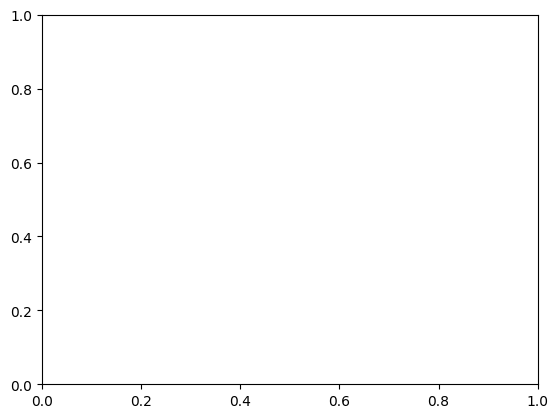

In [63]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

comp_fits_dir = 'D:/work/wavelet/data/comp/fits_20120327_morton/'
comp_fits_list = os.listdir(comp_fits_dir)
already_crop_data = False
ims = []
fig = plt.figure()
ax = plt.subplot()

for comp_fits in comp_fits_list:
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    # print(hdul.info())
    doppler_map = hdul[3].data
    if not already_crop_data:
        sequence_doppler_map = np.copy(doppler_map[530:590, 250:370])
        already_crop_data = True
    else:
        sequence_doppler_map = np.dstack([sequence_doppler_map, doppler_map[530:590, 250:370]])
    # x = np.array(range(np.shape(doppler_map[530:590, 250:370])[1]))*4.46 + (250-310.5)*4.46
    # y = np.array(range(np.shape(doppler_map[530:590, 250:370])[0]))*4.46 + (530-310.5)*4.46
    # im = plt.pcolor(x,y,doppler_map[530:590, 250:370],cmap='seismic',vmin=-10, vmax=10).findobj()
    # plt.xlabel('x [arcsec]')
    # plt.ylabel('y [arcsec]')
    
#     ims.append(im)
#     # plt.cla()
# plt.colorbar(label='km/s')
# ani = animation.ArtistAnimation(fig, ims, interval=100, repeat_delay=1000)
# ani.save("./0327_morton_test_comp.gif", writer='pillow')
# wavelet map sequence
input_data_3D = np.transpose(sequence_doppler_map, (1,0,2))
from_K_Mm_to_K_pixel = 4.46 * 0.721
k_theta = np.sort(1/np.linspace(-30, 30, 10))
# # k_theta = np.sort(1/np.array([-200,-175,-150,-125,-100,100,125,150,175,200]))/30
# lambda_t_arr = np.logspace(np.log10(20),np.log10(200), 5, base=10) ### modified by user
# lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
# k_theta = np.sort(1/lambda_t_arr)        
k_r = 0.005/0.44 * from_K_Mm_to_K_pixel
omega =  0.005 / 12*30
calculate_wavelet_2DT_GPU(input_data_3D, k_theta, k_r, omega)



C:\Users\hcp\AppData\Local\Temp\ipykernel_28648\4056988871.py:22: UserWarning: The following kwargs were not used by contour: 'shading'
  plt.tricontourf(x.reshape(-1), y.reshape(-1), data[:,:,time_idx,0,0].reshape(-1),cmap='jet',levels=30,shading='gouraud')


MemoryError: 

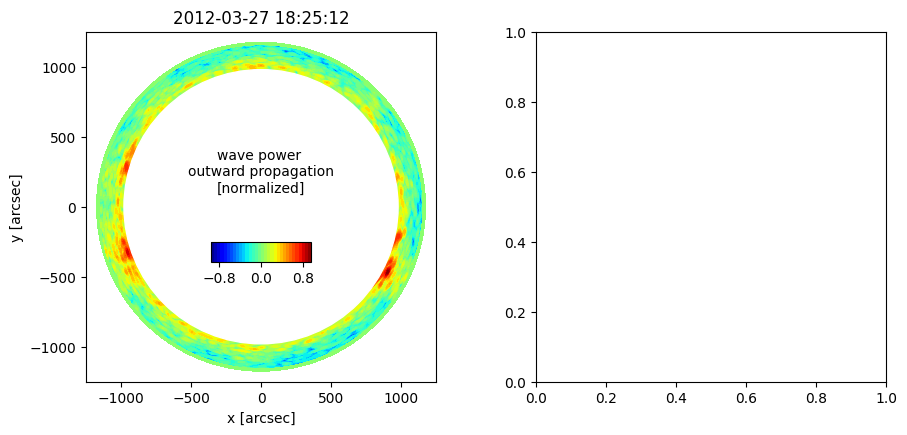

In [236]:
from matplotlib import ticker

data_file = loadmat('D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_0.009831818181818181_k_r_0.005_omega.mat')

data = np.log10(data_file['data'])/np.nanmax(np.log10(data_file['data']))

theta_vect_input = np.linspace(0,359.5,360*5) # unit: deg
r_vect_input = np.linspace(1.02,1.2,int(0.18*960/1.2)) # unit: Rs

theta_grid, r_grid = np.meshgrid(theta_vect_input, r_vect_input, indexing='ij')
x = r_grid * np.cos(theta_grid/180*np.pi) * 960 *1.02
y = r_grid * np.sin(theta_grid/180*np.pi) * 960 *1.02
data[r_grid>1.18]=0

left, width = .25, .5
bottom, height = .25, .5
right = left + width
top = bottom + height
for time_idx in range(np.shape(input_data_3D)[2]):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_axes([0.05,0.4,0.35,0.35])
    plt.tricontourf(x.reshape(-1), y.reshape(-1), data[:,:,time_idx,0,0].reshape(-1),cmap='jet',levels=30,shading='gouraud')
    circle1 = plt.Circle((0, 0), 960*1.02, color='w')
    plt.xlim([-1250,1250])
    plt.ylim([-1250,1250])
    figure_title = calibrate_sequence_map[0].fits_header['DATE-OBS'][0:19].replace('T', ' ')
    plt.text(0.5 * (left + right), 0.5 * (bottom + top)+0.1, 'wave power \noutward propagation\n[normalized]',
              horizontalalignment='center',
              verticalalignment='center',transform=ax.transAxes)
    plt.title(figure_title)
    plt.xlabel('x [arcsec]')
    plt.ylabel('y [arcsec]')
    ax.add_patch(circle1)
    cax = fig.add_axes([0.175,0.52,0.1,0.02]) 
    cb = plt.colorbar(cax=cax, orientation='horizontal')
    tick_locator = ticker.MaxNLocator(nbins=3)
    cb.locator = tick_locator
    cb.update_ticks()

    ax = fig.add_axes([0.5,0.4,0.35,0.35])
    plt.tripcolor(x.reshape(-1), y.reshape(-1), input_data_3D[:,:,time_idx].reshape(-1),cmap='sdoaia171',vmin=-10,vmax=10)
    circle1 = plt.Circle((0, 0), 960*1.02, color='w')
    plt.xlim([-1250,1250])
    plt.ylim([-1250,1250])
    ax.add_patch(circle1)
    plt.text(0.5 * (left + right), 0.5 * (bottom + top)+0.1, 'AIA 171$\AA$ \nenhanced images',
              horizontalalignment='center',
              verticalalignment='center',transform=ax.transAxes)
    plt.title(figure_title)
    plt.xlabel('x [arcsec]')
    plt.ylabel('y [arcsec]')
    cax = fig.add_axes([0.175+0.45,0.52,0.1,0.02])
    cb = plt.colorbar(cax=cax, orientation='horizontal')
    tick_locator = ticker.MaxNLocator(nbins=3)
    cb.locator = tick_locator
    cb.update_ticks()

    plt.savefig('D:/work/wavelet/figure/aia_atrous_wavelet_movie/'+str(time_idx)+'.png', dpi=300, bbox_inches='tight')
    plt.close()



In [239]:
plt.tripcolor(x.reshape(-1), y.reshape(-1), input_data_3D[:,:,time_idx].reshape(-1),cmap='sdoaia171',vmin=-10,vmax=10)

In [200]:
calibrate_sequence_map[0].fits_header['DATE-OBS'][0:19].replace('T', ' ')

'2012-03-27 18:25:12'

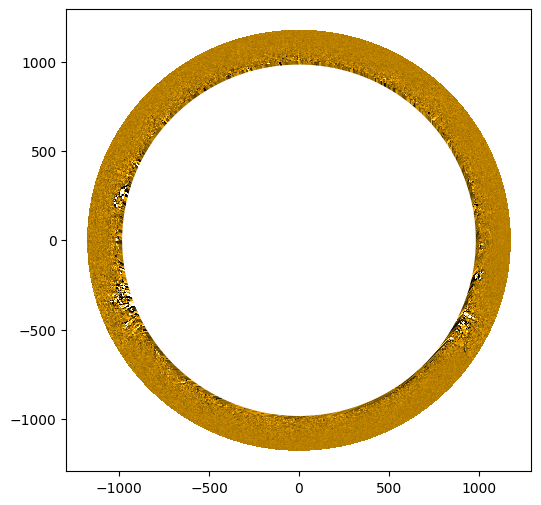

In [183]:
theta_vect_input = np.linspace(0,359.5,360*5) # unit: deg
r_vect_input = np.linspace(1.02,1.2,int(0.18*960/1.2)) # unit: Rs

theta_grid, r_grid = np.meshgrid(theta_vect_input, r_vect_input, indexing='ij')
x = r_grid * np.cos(theta_grid/180*np.pi) * 960 *1.02
y = r_grid * np.sin(theta_grid/180*np.pi) * 960 *1.02

fig = plt.figure(figsize=(6,6))
ax = plt.subplot()
plt.tripcolor(x.reshape(-1), y.reshape(-1), input_data_3D[:,:,30].reshape(-1),cmap='sdoaia171',vmin=-10,vmax=10)
circle1 = plt.Circle((0, 0), 960*1.02, color='w')
ax.add_patch(circle1)



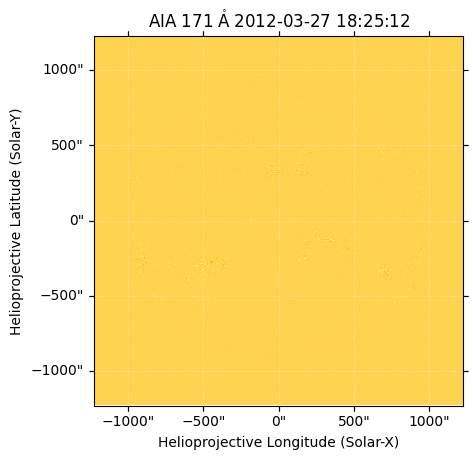

In [185]:
fig = plt.figure()
ax = plt.subplot(projection=calibrate_sequence_map[0])
calibrate_sequence_map[0].plot()

(1800, 144, 101, 1, 1)
1.6064527843144223


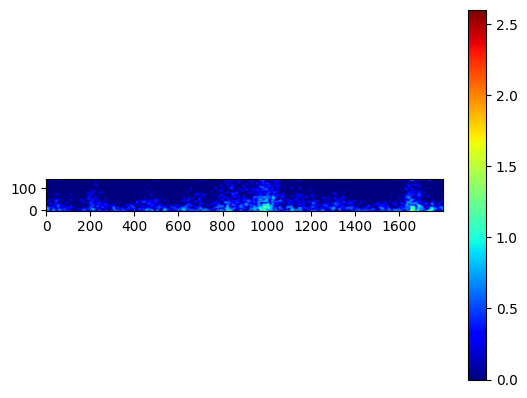

In [153]:
data_file = loadmat('D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_0.017304_k_r_0.004_omega.mat')

data = data_file['data']
print(np.shape(data))
im = plt.imshow(np.log10(data[:,:,30,0,0].T), origin='lower',cmap='jet',vmax=2.6,vmin=0.0)
np.min(np.log10(data[:,:,30,0,0].T))
print(np.mean(data))
plt.colorbar()

(1800, 144, 101, 1, 1)
1.596420959646277


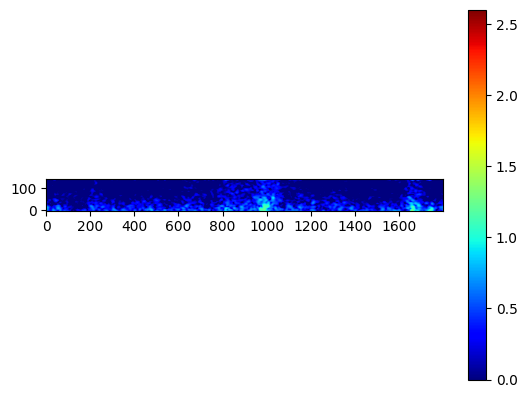

In [145]:
data_file = loadmat('D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_-0.017304_k_r_0.004_omega.mat')

data = data_file['data']
print(np.shape(data))
im = plt.imshow(np.log10(data[:,:,30,0,0].T), origin='lower',cmap='jet',vmax=2.6,vmin=0.0)
np.min(np.log10(data[:,:,30,0,0].T))
print(np.mean(data))
plt.colorbar()

1.086538038812834


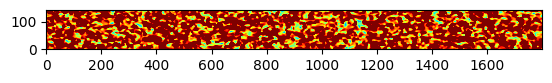

In [148]:
data_file = loadmat('D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_0.017304_k_r_0.004_omega.mat')
data_outward = data_file['data']

data_file = loadmat('D:/work/wavelet/data/wavelet_output_distribution/output_2DT_partial_-0.017304_k_r_0.004_omega.mat')
data_inward = data_file['data']

data = (data_outward/data_inward)

im = plt.imshow((data[:,:,80,0,0]).T, origin='lower',cmap='jet',vmax=1,vmin=0)
print(np.nanmean(data))


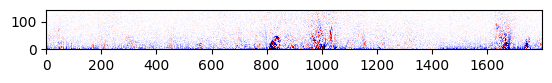

In [169]:
im = plt.imshow(input_data_3D[:,:,30].T, origin='lower',cmap='seismic',vmax=10,vmin=-10)

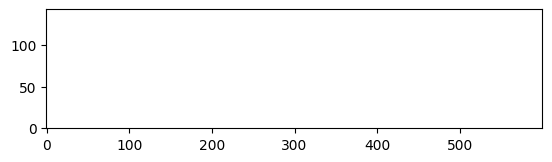

In [25]:
import matplotlib.animation as animation
ims = []
fig = plt.figure()
for t_idx in range(101):
    im = plt.imshow(np.log10(data[:,:,t_idx,0,0].T), origin='lower',cmap='jet',vmax=2.5,vmin=0.0).findobj()
    ims.append(im)

ani = animation.ArtistAnimation(fig, ims, interval=100, repeat_delay=1000)
ani.save("./outward_distribution_wavelet_output.gif", writer='pillow')


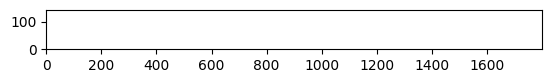

In [225]:
import matplotlib.animation as animation
ims = []
fig = plt.figure()
for t_idx in range(49):
    im = plt.imshow(input_data_3D[:,:,t_idx].T, origin='lower',cmap='sdoaia171',vmax=1,vmin=-1).findobj()
    ims.append(im)

ani = animation.ArtistAnimation(fig, ims, interval=100, repeat_delay=1000)
ani.save("./inward_distribution_wavelet_output.gif", writer='pillow')


In [9]:
dalambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user

# lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
# lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
1/lambda_r_arr

array([-0.125     , -0.08741447, -0.06113032, -0.0427494 , -0.02989533,
       -0.02090628, -0.01462009, -0.01022406, -0.00714985, -0.005     ,
        0.005     ,  0.00714985,  0.01022406,  0.01462009,  0.02090628,
        0.02989533,  0.0427494 ,  0.06113032,  0.08741447,  0.125     ])

In [10]:
1/(lambda_r_arr * 1.2 * 0.721)

array([-0.14447527, -0.10103383, -0.07065456, -0.04940985, -0.03455309,
       -0.02416352, -0.01689793, -0.01181699, -0.00826381, -0.00577901,
        0.00577901,  0.00826381,  0.01181699,  0.01689793,  0.02416352,
        0.03455309,  0.04940985,  0.07065456,  0.10103383,  0.14447527])

In [6]:
lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user


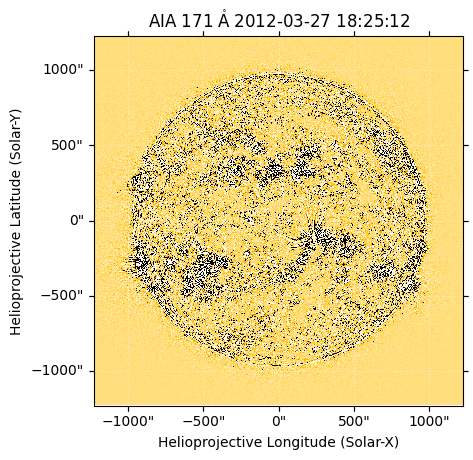

In [134]:
calibrate_sequence_map[0].plot(vmin=-10,vmax=10)

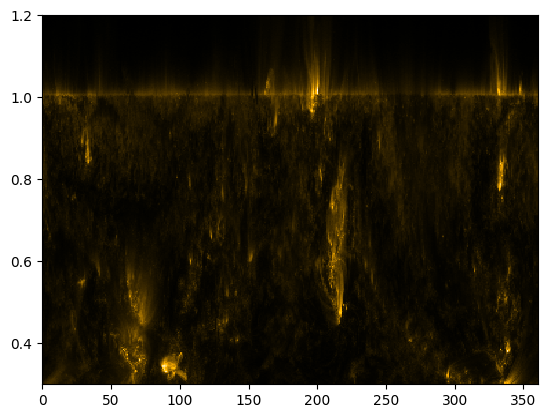

In [154]:
import sys
sys.path.insert(0, '/Users/hcp/opt/anaconda3/lib/python3.8/site-packages/')
import numpy as np
from scipy.interpolate import griddata
import sunpy
import sunpy.map
import matplotlib.pyplot as plt

def convert_to_polar_map(euvmap,r_vect_input,theta_vect_input):

    r_vect = r_vect_input*euvmap.fits_header['RSUN_OBS'] # unit: arcsec
    theta_vect = np.copy(theta_vect_input) # unit: deg

    r_vert_grid, theta_vert_grid = np.meshgrid(r_vect,theta_vect,indexing='ij')
    x_grid = r_vert_grid * np.cos(theta_vert_grid/180*np.pi)
    y_grid = r_vert_grid * np.sin(theta_vert_grid/180*np.pi)
    
    delta_x_pixel_grid = (x_grid - euvmap.fits_header['CRVAL1'])/euvmap.fits_header['CDELT1'] 
    delta_y_pixel_grid = (y_grid - euvmap.fits_header['CRVAL2'])/euvmap.fits_header['CDELT2'] 
    
    interp_grid_x = euvmap.fits_header['CRPIX1'] + delta_x_pixel_grid
    interp_grid_y = euvmap.fits_header['CRPIX2'] + delta_y_pixel_grid
    
    euvmap_shape = np.shape(euvmap.data)
    xxx = np.array(range(euvmap_shape[0]))
    yyy = np.array(range(euvmap_shape[1]))
    points_x,points_y = np.meshgrid(xxx,yyy,indexing='ij')
    points_grid = np.vstack((points_y.reshape(-1),points_x.reshape(-1)))
    values_grid = euvmap.data.reshape(-1)
    grid_z0 = griddata(points_grid.T, values_grid, (interp_grid_x, interp_grid_y), method='nearest')
    return grid_z0

euvmap = sunpy.map.Map('D:/work/wavelet/data/AIA_20min_1825/calibrate_171/calibrate_aia_levl5_euv_12s_2012-03-27T18_25_24.fits')

theta_vect_input = np.linspace(0,360,360) # unit: deg
r_vect_input= np.linspace(0.3,1.2,int(0.2*960/0.6)) # unit: Rs
grid_z0 = convert_to_polar_map(euvmap, r_vect_input, theta_vect_input)
plt.pcolor(theta_vect_input,r_vect_input,grid_z0,cmap='sdoaia171')
plt.show()

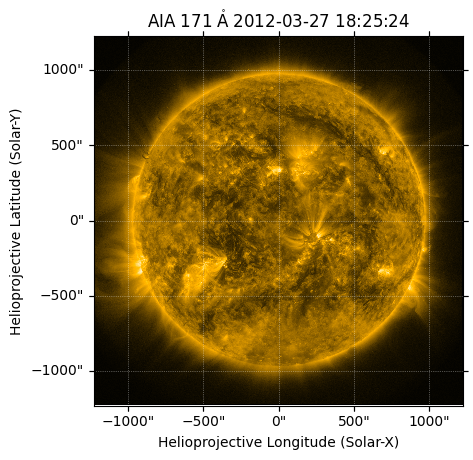

In [153]:
euvmap.plot()